<a href="https://colab.research.google.com/github/lcn781/M11_ARVORES_2_Arvore-de-Regressao/blob/main/Profissao_Cientista_de_Dados_M11_exercicio01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [4]:
import pandas as pd

import seaborn as sns

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split

df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [5]:
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
original_rows = len(df)
df.dropna(subset=['total_bedrooms'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Verify that there are no more missing values in 'total_bedrooms'
print(f"Original number of rows: {original_rows}")
print(f"Number of rows after dropping missing values: {len(df)}")
print(f"Missing values in 'total_bedrooms' after dropping: {df['total_bedrooms'].isnull().sum()}")

Original number of rows: 20433
Number of rows after dropping missing values: 20433
Missing values in 'total_bedrooms' after dropping: 0


### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

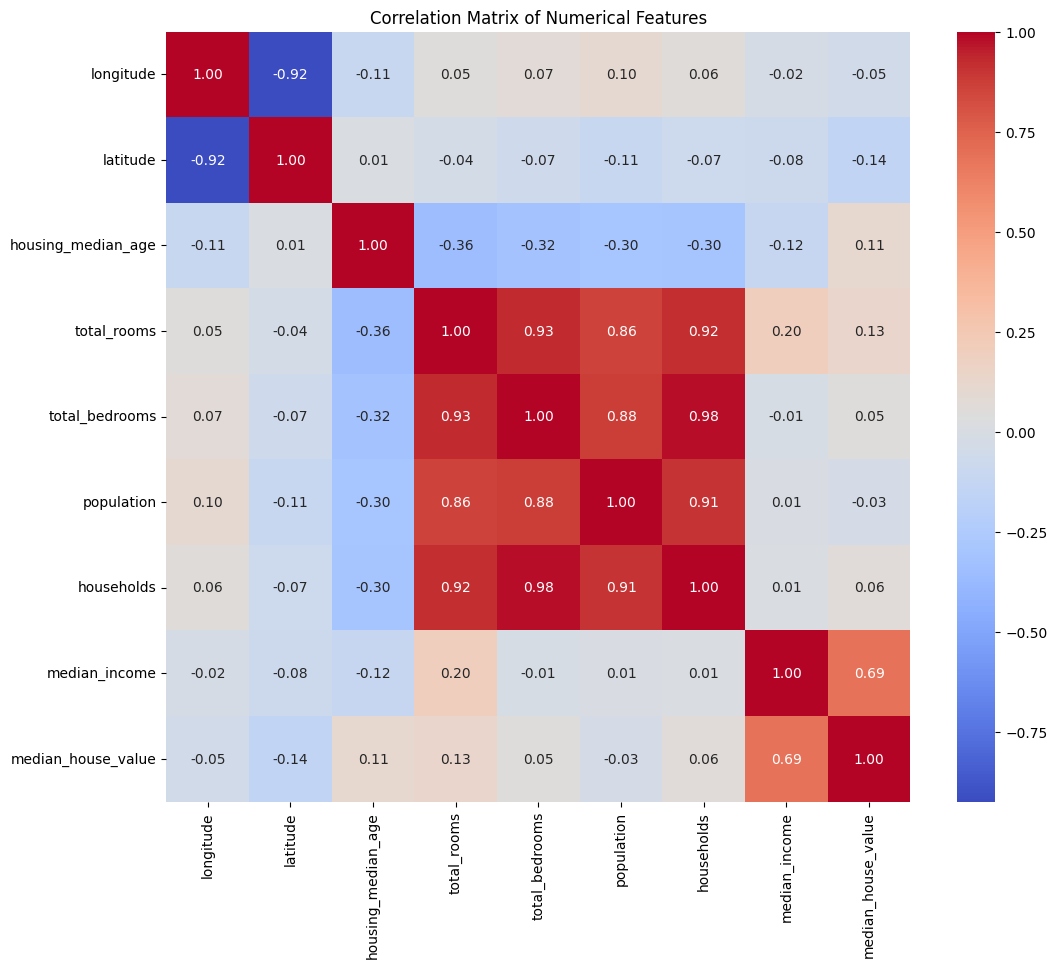

In [12]:
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

A variável que parece ter maior poder preditivo sobre a variável target, é a 'median_income'.

This heatmap visualizes the correlation matrix of the numerical features in your dataset. Values close to 1 or -1 indicate a strong positive or negative linear relationship, respectively, while values close to 0 indicate a weak or no linear relationship. This plot can help in identifying potential predictive variables for the `median_house_value`.

### 3. Separe os dados em validação e teste

In [13]:
# Perform one-hot encoding on the 'ocean_proximity' column
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [14]:
# Define features (X) and target variable (y)
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16346, 12)
X_test shape: (4087, 12)
y_train shape: (16346,)
y_test shape: (4087,)


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [16]:
# Train a Decision Tree Regressor with max_depth = 8
tree_regressor_depth8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_regressor_depth8.fit(X_train, y_train)

# Train a Decision Tree Regressor with max_depth = 2
tree_regressor_depth2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_regressor_depth2.fit(X_train, y_train)

print("Decision trees trained successfully!")

Decision trees trained successfully!


### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [17]:
from sklearn.metrics import mean_squared_error

# Predictions for tree_regressor_depth8
y_train_pred_depth8 = tree_regressor_depth8.predict(X_train)
y_test_pred_depth8 = tree_regressor_depth8.predict(X_test)

# Predictions for tree_regressor_depth2
y_train_pred_depth2 = tree_regressor_depth2.predict(X_train)
y_test_pred_depth2 = tree_regressor_depth2.predict(X_test)

# Calculate MSE for depth=8 tree
mse_train_depth8 = mean_squared_error(y_train, y_train_pred_depth8)
mse_test_depth8 = mean_squared_error(y_test, y_test_pred_depth8)

# Calculate MSE for depth=2 tree
mse_train_depth2 = mean_squared_error(y_train, y_train_pred_depth2)
mse_test_depth2 = mean_squared_error(y_test, y_test_pred_depth2)

print(f"MSE for Decision Tree (max_depth=8) on training set: {mse_train_depth8:.2f}")
print(f"MSE for Decision Tree (max_depth=8) on test set: {mse_test_depth8:.2f}")
print(f"\nMSE for Decision Tree (max_depth=2) on training set: {mse_train_depth2:.2f}")
print(f"MSE for Decision Tree (max_depth=2) on test set: {mse_test_depth2:.2f}")

MSE for Decision Tree (max_depth=8) on training set: 3201632810.13
MSE for Decision Tree (max_depth=8) on test set: 4138506432.59

MSE for Decision Tree (max_depth=2) on training set: 6688828024.52
MSE for Decision Tree (max_depth=2) on test set: 6916498324.43


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

A árvore de profundidade 8 apresenta uma diferença significativa entre o MSE de treino e o MSE de teste. O modelo funciona consideravelmente melhor no conjunto de treino do que no conjunto de teste. Isso sugere que o modelo esteja sofrendo de overfitting.

A árvore com profundidade 2 apresenta uma diferença menor de MSE entre os conjuntos de treino e teste, indicando uma generalização melhor, apesar de o valor do erro ser maior, sugerindo que ela possa estar sofrendo de underfitting.

O modelo ideal provavelmente estaria em algum lugar entre esses dois extremos.

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

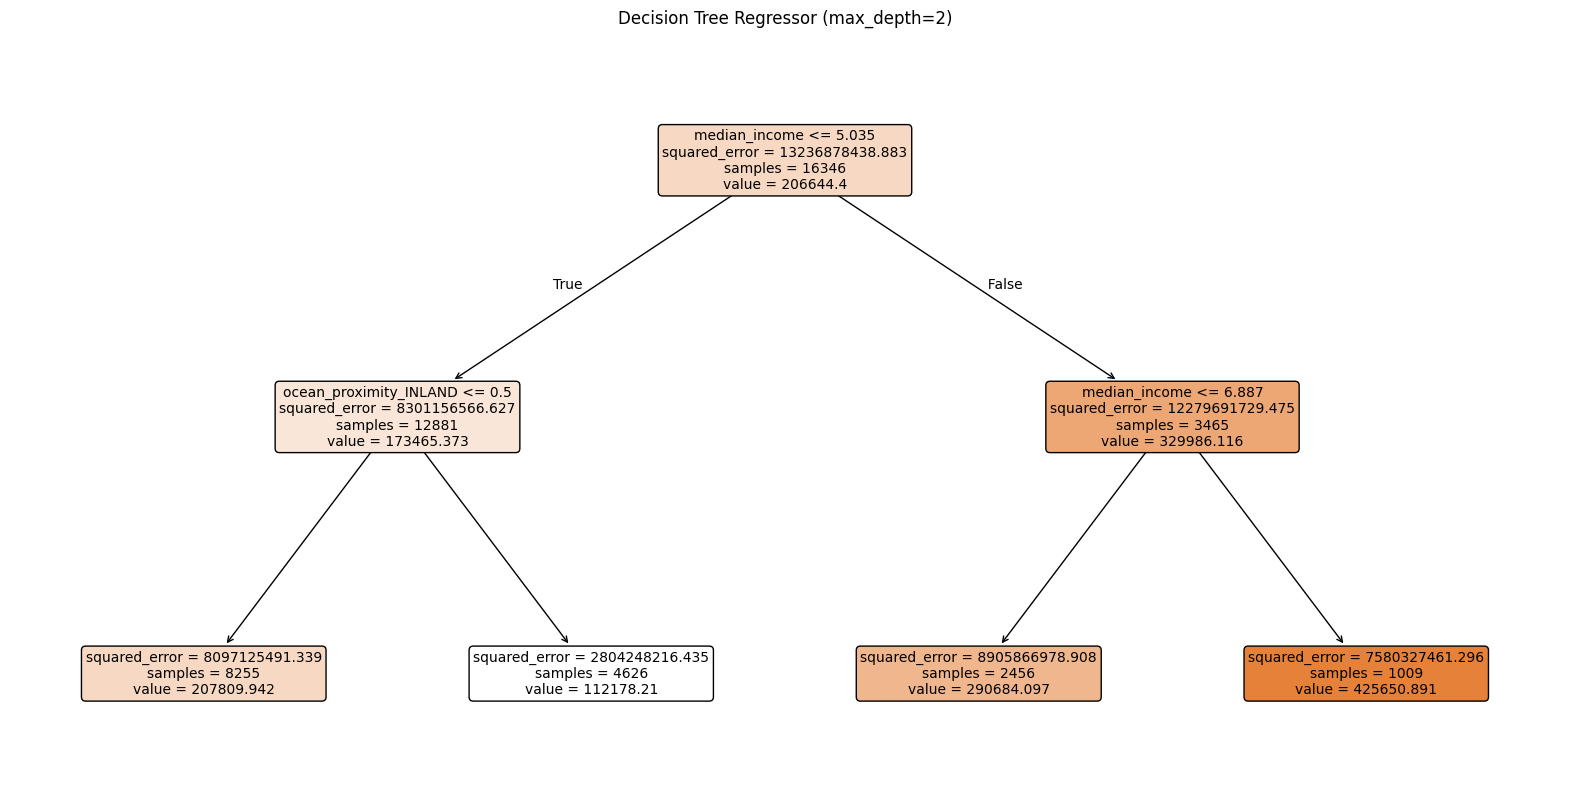

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(tree_regressor_depth2,
               feature_names=X.columns,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree Regressor (max_depth=2)')
plt.show()

This visualization shows the structure of the Decision Tree with a maximum depth of 2. Each node represents a decision rule based on a feature, and the color intensity indicates the `median_house_value` prediction for that node. The `feature_names` help in understanding which features are used at each split. From this tree, you can observe the most important features at the top nodes, as they are used to make the initial splits.

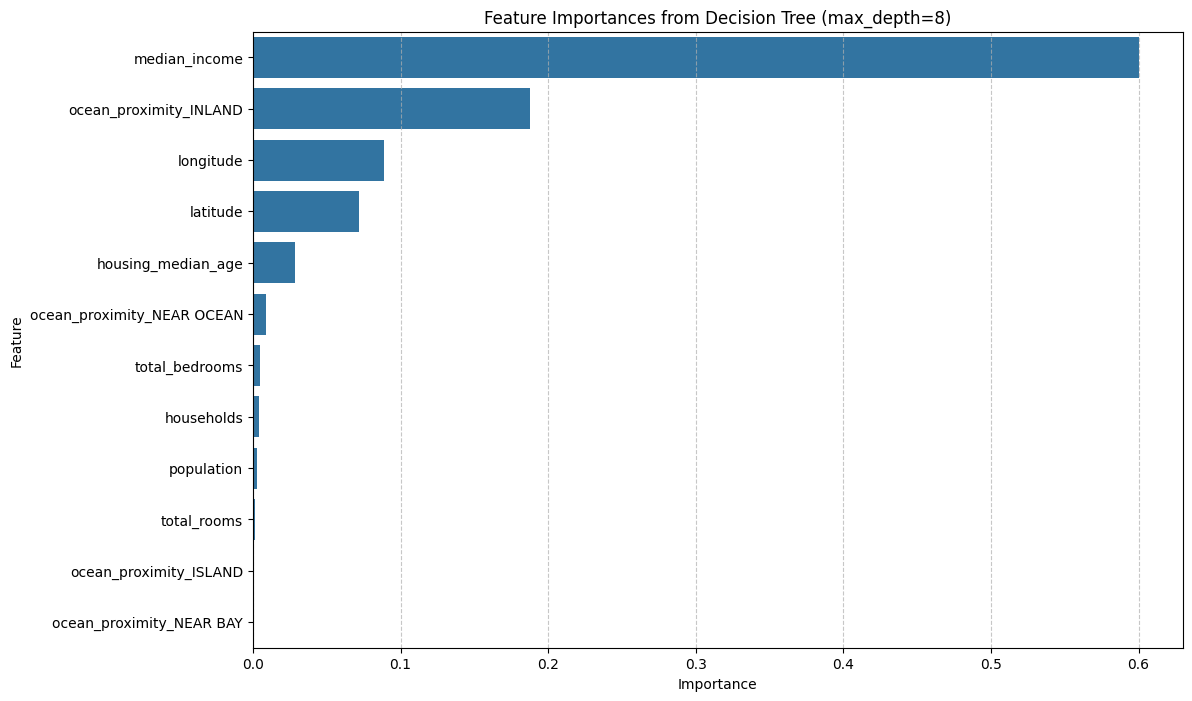

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the tree_regressor_depth8 model
feature_importances = tree_regressor_depth8.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances from Decision Tree (max_depth=8)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

This bar chart displays the importance of each feature in the `max_depth=8` Decision Tree model. Features with higher importance values have a greater impact on the model's decisions and predictions. You can observe which features the model considers most significant in determining the `median_house_value`.

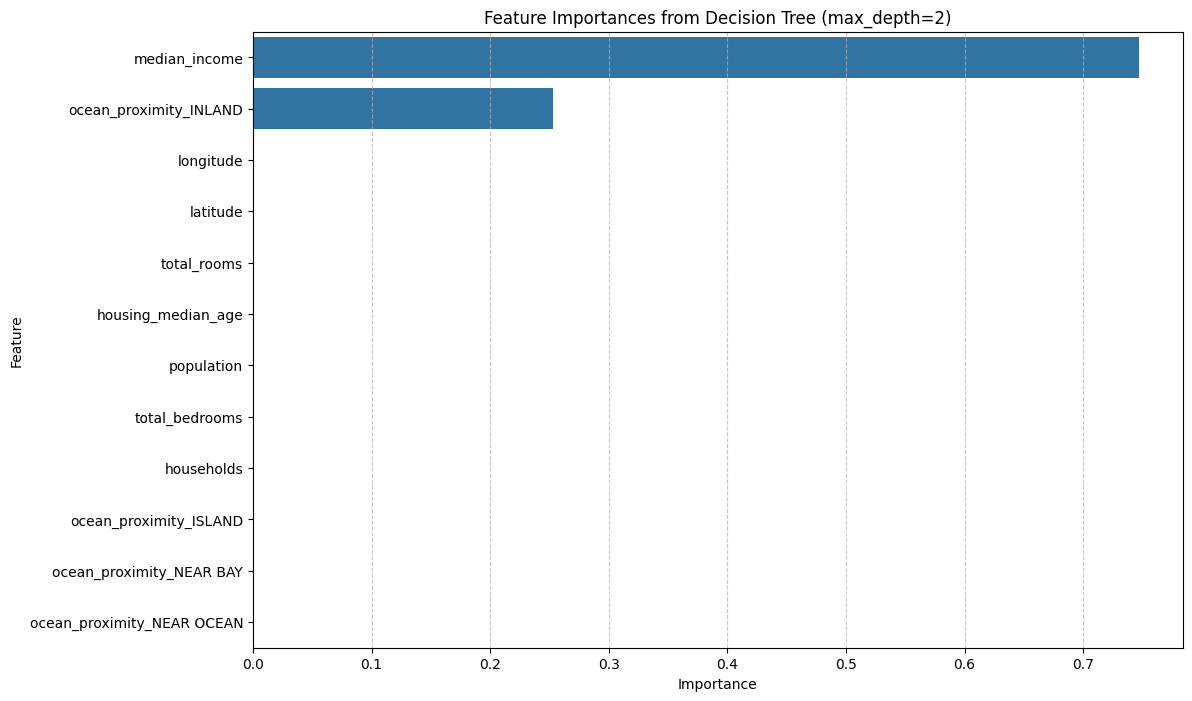

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the tree_regressor_depth2 model
feature_importances_depth2 = tree_regressor_depth2.feature_importances_

# Create a DataFrame for better visualization
features_df_depth2 = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances_depth2})

# Sort features by importance in descending order
features_df_depth2 = features_df_depth2.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df_depth2)
plt.title('Feature Importances from Decision Tree (max_depth=2)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

This bar chart shows the feature importances for the Decision Tree model with `max_depth=2`. As expected, with a shallower tree, fewer features might contribute significantly, and the splits are based on the most dominant features.

Analisando as duas árvores, baseado tanto na matriz de correlação quanto no gráfico de feature importance, a variável 'median_income' aparece consistentemente como a variável que melhor explica a variálce target ('median_house_value).

Isso significa que: quanto mais a variável 'median_income' aumenta, a 'median_house_value' tende a aumentar também, indicando uma forte relação linear entre elas.

Nos dois modelos, a variável 'median_income'apareceu com o maior score de importância. Isso indica que os modelos usam essa variável com frequência na hora de fazer predições, sugerindo que é o fator mais influente na hora de diferenciar os valores das casas.

'median_income' fornece a melhor informação para predizer 'median_house_value', tornando-a a feature mais dominante nesses modelos.